In [52]:
import matplotlib
import cv2 as cv
from scipy.signal import butter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import scipy.fft as fft
from PIL import Image, ImageSequence

(Text(0.5, 1.0, 'Downscaled'), [], [])

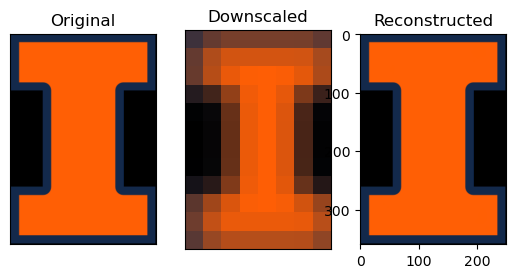

In [51]:

# Returns a "levels"-deep Laplacian pyramid of the given frame
def pyramidDownSample(frame, levels=5):
    G = frame.astype(np.float32)
    samples = [G]

    for i in range(levels):
        G = cv.pyrDown(G)
        samples.append(G)
    laplacianBase = samples[levels]
    laplacians = []
    for i in range(levels,0,-1):
        upsampled = cv.pyrUp(samples[i])
        upsampled = cv.resize(upsampled, (samples[i-1].shape[1], samples[i-1].shape[0]))
        L = cv.subtract(samples[i-1], upsampled)
        laplacians.append(L)
    return laplacianBase, laplacians

# Reconstructs the original image
def pyramidReconstruct(base, laplacians):
    G = base
    for L in laplacians:
        G = cv.pyrUp(G)
        G = cv.resize(G, (L.shape[1], L.shape[0]))
        G = cv.add(G, L)
    return G

image = cv.imread("illinois.png")
lB, lS = pyramidDownSample(image)
reconstructed = pyramidReconstruct(lB, lS)
reconstructed = np.clip(reconstructed, 0, 255,).astype(np.uint8)
fig, axes = plt.subplots(1, 3)
axes[0].imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
axes[0].set_title('Original'), axes[0].set_xticks([]), axes[0].set_yticks([])
axes[2].imshow(cv.cvtColor(reconstructed, cv.COLOR_BGR2RGB))
axes[2].set_title('Reconstructed'), axes[1].set_xticks([]), axes[1].set_yticks([])
lB = np.clip(lB, 0, 255).astype(np.uint8)
axes[1].imshow(cv.cvtColor(lB, cv.COLOR_BGR2RGB))
axes[1].set_title('Downscaled'), axes[1].set_xticks([]), axes[1].set_yticks([])




In [55]:
video = cv.VideoCapture("guitar-strumming.gif")
fps = video.get(cv.CAP_PROP_FPS)
print(fps)

10.0


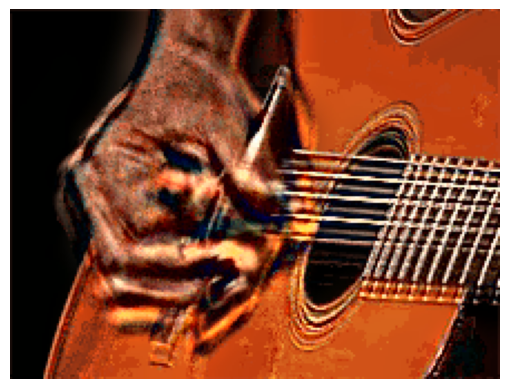

In [ ]:
# Ideal Temporal Filter

levels = 3
alpha = 10
laplacian_stack = [[] for _ in range(levels)]
base_stack = []

while(True):
    ret, levelFrame = video.read()
    if not ret:
        break
    baseFrame, laplacians = pyramidDownSample(cv.cvtColor(levelFrame, cv.COLOR_BGR2YUV), levels)
    base_stack.append(baseFrame)
    for i in range(levels):
        laplacian_stack[i].append(laplacians[i])

video.release()
cv.destroyAllWindows()

for i in range(levels):
    laplacian_stack[i] = np.array(laplacian_stack[i])
base_stack = np.array(base_stack)

N = len(base_stack)
freqs = np.fft.fftfreq(N, d=(1.0/fps))
mask = (np.abs(freqs) >= 0.83) & (np.abs(freqs) <= 1.0)

amplified_ls = []

for stack in laplacian_stack:
    decomp = np.fft.fft(stack, axis=0)
    decomp[~mask] = 0
    filtered = np.fft.ifft(decomp, axis=0).real
    amplified_stack = stack + (alpha * filtered)
    amplified_ls.append(amplified_stack)

final_frames = []
for e in range(len(base_stack)):
    currlap = [amplified_ls[i][e] for i in range(levels)]
    reconstructed = pyramidReconstruct(base_stack[e], currlap)
    final_rgb = cv.cvtColor(np.clip(reconstructed, 0, 255).astype(np.uint8), cv.COLOR_YUV2RGB)
    final_frames.append(final_rgb)

fig, ax = plt.subplots()
ax.axis('off')
im = ax.imshow(final_frames[0])
def update(frame):
    im.set_data(frame)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=final_frames, interval=50, blit=True)
ani.save("temporaloutput.mp4")


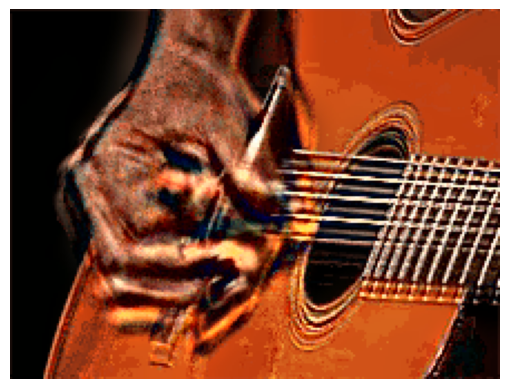

In [ ]:
# Butterworth Filter

levels = 3
alpha = 10
laplacian_stack = [[] for _ in range(levels)]
base_stack = []

b, a = butter(N=1, Wn=[0.83, 1.0], btype='bandpass', fs=fps)
prev_x = [np.zeros_like(l) for l in laplacians]
prev_y = [np.zeros_like(l) for l in laplacians]


while(True):
    ret, levelFrame = video.read()
    if not ret:
        break
    baseFrame, laplacians = pyramidDownSample(cv.cvtColor(levelFrame, cv.COLOR_BGR2YUV), levels)
    base_stack.append(baseFrame)
    for i in range(levels):
        x_curr = laplacians[i]
        y_curr = (b[0]*x_curr + b[1]*prev_x[i][0] + b[2]*prev_x[i][1] 
              - a[1]*prev_y[i][0] - a[2]*prev_y[i][1]) / a[0]
        prev_x[i] = [x_curr, prev_x[i][0]]
        prev_y[i] = [y_curr, prev_y[i][0]]
        laplacians[i] = x_curr + (alpha * y_curr)
        laplacian_stack[i].append(laplacians[i])

video.release()
cv.destroyAllWindows()



fig, ax = plt.subplots()
ax.axis('off')
im = ax.imshow(final_frames[0])
def update(frame):
    im.set_data(frame)
    return [im]

ani = animation.FuncAnimation(fig, update, frames=final_frames, interval=50, blit=True)
ani.save("butterworthoutput.mp4")
